# Call Density Estimatation of Burrowing Owls

Inspired by:
https://github.com/google-research/perch/blob/75fdf0f6ae4055e68dd5037b29a872fc5edcf3f3/chirp/inference/call_density.py#L203

In [ ]:
import pandas as pd

df = pd.read_csv("all_model_redictions_96545a6b81b24794962d464e8fcbdc1d.csv")

# Step 1) Get P(z)

<Axes: >

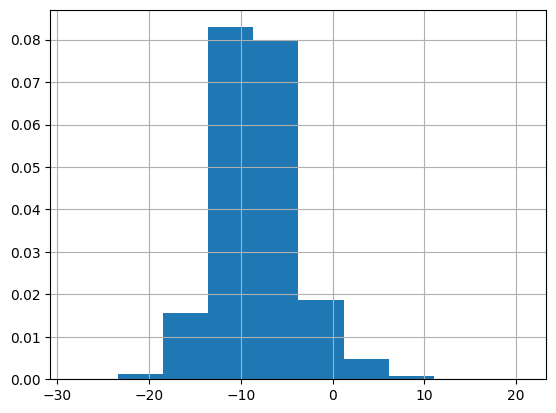

In [ ]:
# This would be P(z) in the paper

df["alarm"].hist(density=True)

# Step 2) Identify Log bins and thier probabilities

In [ ]:
# Apply log bins for k=4
bins = []
bin_prob = [0.5, 0.25, 0.125, 0.125] # basically come naturally from quartiles
for i in [0, 0.5, 0.75, 0.75 + 0.125, 1]:
    bins.append(df["alarm"].quantile(i))
df["alarm_log_bins"] = pd.cut(df["alarm"], bins)

# Step 3) Verify each example

In [ ]:
to_verify_examples = df.groupby(by="alarm_log_bins").sample(25)
to_verify_examples

/tmp/ipykernel_2593232/559746205.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  to_verify_examples = df.groupby(by="alarm_log_bins").sample(25)


,Unnamed: 0,file_path,offset,confidence,pred_label,cluck,coocoo,twitter,alarm,chick_begging,alarm_log_bins
1599175,1599175,/mnt/restorage/Audiomoth/Raw sound files/2024/...,63507,1.000000,no_buow,-23.064388,-19.736938,-16.949842,-13.193549,-18.934590,"(-28.257, -8.527]"
1480307,1480307,/mnt/restorage/Audiomoth/Raw sound files/2024/...,52494,1.000000,no_buow,-18.733479,-20.272316,-15.858214,-13.543464,-13.123668,"(-28.257, -8.527]"
2661157,2661157,/mnt/restorage/Audiomoth/Raw sound files/2024/...,3501,1.000000,no_buow,-26.100376,-24.571936,-21.153044,-11.399319,-20.816217,"(-28.257, -8.527]"
1415229,1415229,/mnt/restorage/Audiomoth/Raw sound files/2024/...,960,1.000000,no_buow,-19.894716,-21.799314,-18.136360,-9.197646,-17.037483,"(-28.257, -8.527]"
70442,70442,/mnt/restorage/Audiomoth/Raw sound files/2024/...,38526,1.000000,no_buow,-19.792253,-19.134663,-12.156043,-10.074691,-16.025242,"(-28.257, -8.527]"
...,...,...,...,...,...,...,...,...,...,...,...
2449912,2449912,/mnt/restorage/Audiomoth/Raw sound files/2024/...,2586,0.833507,no_buow,-11.360384,-13.253312,-10.244439,-0.158789,-8.836505,"(-3.863, 20.842]"
2205911,2205911,/mnt/restorage/Audiomoth/Raw sound files/2024/...,4311,0.779768,no_buow,-16.454424,-18.090397,-17.984997,-1.158788,-12.756640,"(-3.863, 20.842]"
880261,880261,/mnt/restorage/Audiomoth/Raw sound files/2024/...,49704,0.999983,alarm,-6.844182,-9.517516,-11.382256,5.326016,-6.316499,"(-3.863, 20.842]"
678824,678824,/mnt/restorage/Audiomoth/Raw sound files/2024/...,6687,0.992792,no_buow,-11.359989,-10.731770,-9.876309,-3.849613,-4.718785,"(-3.863, 20.842]"


In [ ]:
# 0 is true, 1 is false, 2 is unsure
verified = []

In [ ]:
import librosa
import numpy as np
from IPython.display import Audio
from IPython.display import clear_output

for i, row in to_verify_examples.iterrows():
    if i < len(verified):
        continue
    y, sr = librosa.load(path=row["file_path"], offset=row["offset"], duration=3)
    display(Audio(data=y, rate=sr))
    # fig.savefig(f"data/burrowing_owl_dataset/img/{file_meta["path"][-20:]}_{file_meta["offset"]}_spec.jpg")


    print(
        i, row["file_path"],
        "\t", row["offset"],
        )
    verified.append(int(input("Correct Prediction of Alarm Call? 0,1,2")))
    clear_output(wait=True)



/home/sean/whoot/.venv/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


1599175 /mnt/restorage/Audiomoth/Raw sound files/2024/RGCB/RGCB04/B030/20240524-0607_030_continuous/20240528_000002.WAV 	 63507


KeyboardInterrupt: Interrupted by user

In [ ]:
to_verify_examples["verifications"] = verified
to_verify_examples["verifications"].value_counts()

ValueError: Length of values (0) does not match length of index (100)

In [ ]:
to_verify_examples.to_csv("verified.csv")

# Bootstrap beta distrbution

In [ ]:
to_verify_examples = pd.read_csv("verified.csv")
to_verify_examples

,Unnamed: 0.1,Unnamed: 0,file_path,offset,confidence,pred_label,cluck,coocoo,twitter,alarm,chick_begging,alarm_log_bins,verifications
0,299305,299305,/mnt/restorage/Audiomoth/Raw sound files/2024/...,33918,1.000000,no_buow,-15.410941,-18.296083,-17.915430,-8.985768,-16.763140,"(-28.257, -8.527]",1
1,2545239,2545239,/mnt/restorage/Audiomoth/Raw sound files/2024/...,1167,1.000000,no_buow,-23.824436,-21.639332,-17.270765,-12.279693,-13.664545,"(-28.257, -8.527]",1
2,624415,624415,/mnt/restorage/Audiomoth/Raw sound files/2024/...,1560,1.000000,no_buow,-27.241901,-25.197578,-21.947922,-12.163423,-20.998112,"(-28.257, -8.527]",1
3,58077,58077,/mnt/restorage/Audiomoth/Raw sound files/2024/...,1431,1.000000,no_buow,-18.556290,-19.480380,-15.301119,-9.897387,-16.779707,"(-28.257, -8.527]",1
4,258723,258723,/mnt/restorage/Audiomoth/Raw sound files/2024/...,17862,1.000000,no_buow,-29.471395,-26.496117,-21.200079,-11.396408,-22.946188,"(-28.257, -8.527]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2042140,2042140,/mnt/restorage/Audiomoth/Raw sound files/2024/...,45432,0.997088,no_buow,-7.325077,-10.923778,-7.755750,-2.867459,-8.154048,"(-3.863, 20.842]",1
96,1350213,1350213,/mnt/restorage/Audiomoth/Raw sound files/2024/...,7092,0.563047,no_buow,-10.729084,-13.096967,-11.313320,-0.161362,-9.160922,"(-3.863, 20.842]",1
97,1327806,1327806,/mnt/restorage/Audiomoth/Raw sound files/2024/...,11751,0.882563,alarm,-0.640454,-7.889000,-7.158687,1.412363,-5.176679,"(-3.863, 20.842]",1
98,1771795,1771795,/mnt/restorage/Audiomoth/Raw sound files/2024/...,16047,0.976355,alarm,-6.886403,-10.031792,-8.497675,1.852985,-4.739240,"(-3.863, 20.842]",1


In [ ]:
from scipy.stats import beta

In [ ]:
k_at_bins = to_verify_examples.groupby("alarm_log_bins")["verifications"].value_counts().reset_index()

In [ ]:
betas = {}
c = 0.01
for bin_id in k_at_bins["alarm_log_bins"].unique():
    k_at_bin = k_at_bins[k_at_bins["alarm_log_bins"] == bin_id]
    k_at_bin = k_at_bin.set_index("verifications")
    k_at_bin = k_at_bin[["count"]]

    k_pos = k_at_bin.loc[0]["count"] if 0 in k_at_bin.index else 0
    k_neg = k_at_bin.loc[1]["count"] if 1 in k_at_bin.index else 0
    
    
    print(bin_id, k_pos + c, k_neg + c)
    betas[bin_id] = beta(k_pos + c, k_neg + c)
betas

(-28.257, -8.527] 0.01 24.01
(-3.863, 20.842] 4.01 21.01
(-5.968, -3.863] 1.01 22.01
(-8.527, -5.968] 0.01 23.01


{'(-28.257, -8.527]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79da2ad0>,
 '(-3.863, 20.842]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79da2310>,
 '(-5.968, -3.863]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79dc9e90>,
 '(-8.527, -5.968]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79dc9090>}

In [ ]:
P_b = dict(zip(list(pd.cut(df["alarm"], bins).cat.categories.to_tuples()), bin_prob))

betas['(-28.257, -8.527]'].rvs(10000) * P_b[(-28.257, -8.527)]

array([1.15408898e-012, 2.13632874e-003, 2.41695876e-082, ...,
       1.44543376e-032, 4.58667158e-106, 2.81661557e-056])

In [ ]:
betas

{'(-28.257, -8.527]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79da2ad0>,
 '(-3.863, 20.842]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79da2310>,
 '(-5.968, -3.863]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79dc9e90>,
 '(-8.527, -5.968]': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f5b79dc9090>}

In [ ]:
P_b

{(-28.257, -8.527): 0.5,
 (-8.527, -5.968): 0.25,
 (-5.968, -3.863): 0.125,
 (-3.863, 20.842): 0.125}

In [ ]:
bootstrap_n = 10_000
P_pos = np.zeros(bootstrap_n)
for intval in P_b.keys():
    P_pos += betas[str(intval).replace(")", "]")].rvs(10000) * P_b[intval]
P_pos

array([0.01690698, 0.02571758, 0.01673479, ..., 0.04427622, 0.04023263,
       0.01953617])

<Axes: ylabel='Count'>

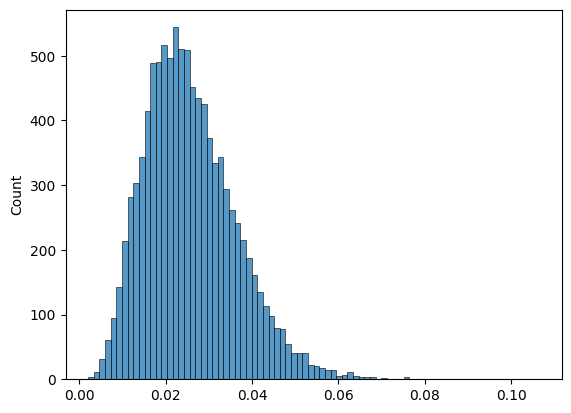

In [ ]:
import seaborn as sns

sns.histplot(P_pos)

In [ ]:
(np.quantile(P_pos, 0.95) - np.quantile(P_pos, 0.05))/2, np.quantile(P_pos, 0.5), 

(0.01698262027442897, 0.024404618143955614)

$ 0.0244 \pm 0.0171$

In [ ]:
def generate_bins(n_bins):
    bin_probs = [1/(2**i) for i in range(1, n_bins)]
    bin_probs.append(1 - sum(bin_probs))
    print(bin_probs)
    bins = np.cumsum([0] + bin_prob)

    bin_labels = [(bins[i], bins[i+1]) for i in range(len(bins)-1)]
    return bin_probs, bins, bin_labels

In [ ]:
class CallDensity():
    def __init__(
            self, 
            model_confidence_species_scores,
            file_paths,
            offsets,
            n_bins=4,
            labeled_data=None, #{index_of_score: label} 0 for correct, 1 for missing, 2 for unsure
            segment_duration=3
            ):
        self.P_z = pd.DataFrame({
            "scores": model_confidence_species_scores, 
            "file_path": file_paths,
            "offset": offsets
        })
        self.bin_probs, self.bins, self.bin_labels = generate_bins(n_bins)
        self.labeled_data=labeled_data
        
        self.P_z["bins"] =  pd.cut(self.P_z["scores"], bins, labels=self.bin_labels)
        self.P_b = dict(zip(list(self.P_z["bins"].cat.categories), bin_prob))
        self.segment_duration = segment_duration

    def verify(self, k_samples=25, verified=None, duration=3, to_verify_examples=None):
        if verified is None:
            to_verify_examples = self.P_z.groupby(by="bins").sample(k_samples)
            verified = []


        for i, row in to_verify_examples.reset_index().iterrows():
            try:
                if i < len(verified):
                    continue
                y, sr = librosa.load(path=row["file_path"], offset=row["offset"], duration=self.segment_duration)
                display(Audio(data=y, rate=sr, autoplay=True, normalize=True))

                print(
                    i, row["file_path"],
                    "\t", row["offset"],
                    )
                verified.append(int(input("Correct Prediction of Alarm Call? 0,1,2")))
                clear_output(wait=True)
            except Exception as e:
                print(e)
                print("Saving progress we have verified already")
                return to_verify_examples, verified
        
        to_verify_examples["verifications"] = verified
        self.labeled_data = to_verify_examples["verifications"].to_dict()
        print("Completed Verification!")
        return to_verify_examples, verified
    
    def compute_call_density(self, c = 0.01, bootstrap_n = 10_000):
        if self.labeled_data is None:
            print("please verify a sample of data with `verify()`")
            return -1
        
        verfied_examples = self.P_z.loc[list(self.labeled_data.keys())]
        verfied_examples["verifications"] = self.labeled_data.values()
        k_at_bins = verfied_examples.groupby("bins")["verifications"].value_counts().reset_index()
        betas = {}
        for bin_id in self.bin_labels:
            k_at_bin = k_at_bins[k_at_bins["bins"] == bin_id]
            k_at_bin = k_at_bin.set_index("verifications")
            k_at_bin = k_at_bin[["count"]]

            k_pos = k_at_bin.loc[0]["count"] if 0 in k_at_bin.index else 0
            k_neg = k_at_bin.loc[1]["count"] if 1 in k_at_bin.index else 0
            betas[bin_id] = beta(k_pos + c, k_neg + c)
        
        P_pos = np.zeros(bootstrap_n)
        for intval in self.bin_labels:
            P_pos += betas[intval].rvs(10000) * self.P_b[intval]
        
        print("Call Density of Call is:", np.quantile(P_pos, 0.5), "+/-", (np.quantile(P_pos, 0.95) - np.quantile(P_pos, 0.05))/2)
        return verfied_examples, k_at_bins, betas, P_pos
        



CallDensity(
    df["alarm"].values,
    df["file_path"].values,
    df["offset"].values,
    labeled_data=to_verify_examples.set_index("Unnamed: 0")["verifications"].to_dict()
).compute_call_density()

KeyError: "None of ['Unnamed: 0'] are in the columns"

In [ ]:
call_density_of_cb = CallDensity(
    df["chick_begging"].values,
    df["file_path"].values,
    df["offset"].values,
)

call_density_of_cb

[0.5, 0.25, 0.125, 0.125]


In [ ]:
to_verify_examples, verified =  call_density_of_cb.verify(verified=verified[:-1], to_verify_examples=to_verify_examples)

Completed Verification!


In [ ]:
call_density_of_cb.compute_call_density()

Call Density of Call is: 0.23627913944613405 +/- 0.07167135600941728


/tmp/ipykernel_2593232/2098484948.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  k_at_bins = verfied_examples.groupby("bins")["verifications"].value_counts().reset_index()


(            scores                                          file_path  offset  \
 2672188 -13.251352  /mnt/restorage/Audiomoth/Raw sound files/2024/...   36594   
 1908323 -16.922860  /mnt/restorage/Audiomoth/Raw sound files/2024/...    3261   
 2149397 -13.755006  /mnt/restorage/Audiomoth/Raw sound files/2024/...    7209   
 1876929 -14.725753  /mnt/restorage/Audiomoth/Raw sound files/2024/...   52959   
 38085   -15.599475  /mnt/restorage/Audiomoth/Raw sound files/2024/...   27855   
 ...            ...                                                ...     ...   
 1769398  -3.172868  /mnt/restorage/Audiomoth/Raw sound files/2024/...    8856   
 2093960   2.035002  /mnt/restorage/Audiomoth/Raw sound files/2024/...   28095   
 1487845   0.605280  /mnt/restorage/Audiomoth/Raw sound files/2024/...    7998   
 1703984  -2.370850  /mnt/restorage/Audiomoth/Raw sound files/2024/...    9024   
 1331543   5.206202  /mnt/restorage/Audiomoth/Raw sound files/2024/...    8562   
 
              

# All together

In [ ]:
import pandas as pd

df = pd.read_csv("all_model_redictions_96545a6b81b24794962d464e8fcbdc1d.csv")

In [ ]:
df

,Unnamed: 0,file_path,offset,confidence,pred_label,cluck,coocoo,twitter,alarm,chick_begging
0,0,/mnt/restorage/Audiomoth/Raw sound files/2024/...,0,0.999725,no_buow,-8.033626,-10.700133,-9.558512,-5.248100,-9.820652
1,1,/mnt/restorage/Audiomoth/Raw sound files/2024/...,3,0.999999,no_buow,-16.056010,-15.497064,-15.369016,-7.080927,-16.350336
2,2,/mnt/restorage/Audiomoth/Raw sound files/2024/...,6,0.999999,no_buow,-16.035126,-18.107718,-14.345729,-7.202197,-15.839329
3,3,/mnt/restorage/Audiomoth/Raw sound files/2024/...,9,1.000000,no_buow,-24.267057,-24.312159,-21.880032,-15.378051,-19.277124
4,4,/mnt/restorage/Audiomoth/Raw sound files/2024/...,12,0.999998,no_buow,-13.226201,-14.365666,-10.647402,-6.698857,-11.873996
...,...,...,...,...,...,...,...,...,...,...
2717585,2717585,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19275,0.999999,no_buow,-10.944146,-15.609729,-13.065670,-8.628973,-8.438443
2717586,2717586,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19278,0.999998,no_buow,-12.509136,-15.327887,-13.333993,-7.184457,-8.196310
2717587,2717587,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19281,1.000000,no_buow,-20.186127,-21.237795,-18.481756,-10.260230,-13.428183
2717588,2717588,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19284,1.000000,no_buow,-13.028744,-17.093920,-15.765416,-9.312826,-10.998377


In [ ]:


CallDensity(
    df["chick_begging"].values,
    df["file_path"].values,
    df["offset"].values,
).compute_call_density()
CallDensity(
    df["alarm"].values,
    df["file_path"].values,
    df["offset"].values,
).compute_call_density()
CallDensity(
    df["cluck"].values,
    df["file_path"].values,
    df["offset"].values,
).compute_call_density()
CallDensity(
    df["coocoo"].values,
    df["file_path"].values,
    df["offset"].values,
).compute_call_density()
CallDensity(
    df["twitter"].values,
    df["file_path"].values,
    df["offset"].values,
).compute_call_density()

"done"